In [1]:
import pandas as pd
import duckdb
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent

if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))

from src.utils.data_loader import load_datasets
from src.services.bcb_api import fetch_exchange_rates

dfs = load_datasets(["vendas_2023_2024.csv"], layer="raw")
dfs.update(load_datasets(["produtos_processed.csv", "custos_importacao_processed.csv"]))

df_sales = dfs["vendas_2023_2024.csv"]
df_products = dfs["produtos_processed.csv"]
df_costs = dfs["custos_importacao_processed.csv"]

df_sales["sale_date"] = pd.to_datetime(df_sales["sale_date"], format="mixed", dayfirst=True).dt.date
df_costs["start_date"] = pd.to_datetime(df_costs["start_date"], format="mixed", dayfirst=True).dt.date

df_rates = fetch_exchange_rates("01-01-2023", "12-31-2024")

In [2]:
query_q4 = """
WITH current_costs AS (
    SELECT
        s.id_product,
        s.sale_date,
        s.total AS revenue_brl,
        s.qtd,
        c.usd_price
    FROM df_sales s
    ASOF LEFT JOIN df_costs c
        ON s.id_product = c.product_id
       AND s.sale_date >= c.start_date
),
financial_calc AS (
    SELECT
        cc.id_product,
        cc.revenue_brl,
        fx.usd_rate,
        (cc.usd_price * fx.usd_rate * cc.qtd) AS cost_brl,
        cc.revenue_brl - (cc.usd_price * fx.usd_rate * cc.qtd) AS profit_margin
    FROM current_costs cc
    ASOF LEFT JOIN df_rates fx
        ON cc.sale_date >= fx.rate_date
),
aggregated_metrics AS (
    SELECT
        id_product,
        SUM(revenue_brl) AS raw_revenue,
        SUM(CASE WHEN profit_margin < 0 THEN ABS(profit_margin) ELSE 0 END) AS raw_loss,
        SUM(CASE WHEN profit_margin < 0 THEN ABS(profit_margin) ELSE 0 END) / NULLIF(SUM(revenue_brl), 0) AS raw_loss_pct
    FROM financial_calc
    GROUP BY id_product
)
SELECT
    a.id_product,
    p.name AS product_name,
    ROUND(a.raw_revenue, 2) AS total_revenue,
    ROUND(a.raw_loss, 2) AS total_loss,
    ROUND(a.raw_loss_pct * 100, 2)::VARCHAR || '%' AS loss_percentage
FROM aggregated_metrics a
LEFT JOIN df_products p
    ON a.id_product = p.code
ORDER BY a.raw_loss_pct DESC;
"""

df_fct_profitability = duckdb.query(query_q4).df()

In [9]:
top_loss_product = df_fct_profitability.iloc[0]

print("=" * 20)
print(f"Produto: {top_loss_product['product_name']} (ID {int(top_loss_product['id_product'])})")
print(f"Prejuízo Relativo: {top_loss_product['loss_percentage']} sobre a receita.")
print(f"Prejuízo Absoluto Total: R$ {top_loss_product['total_loss']:,.2f}")
print("=" * 20,"\n")

print(df_fct_profitability.head(10).to_string(index=False))

Produto: Motor de Popa Volvo Hydro Dash 256HP (ID 72)
Prejuízo Relativo: 63.37% sobre a receita.
Prejuízo Absoluto Total: R$ 39,959,694.85

 id_product                            product_name  total_revenue  total_loss loss_percentage
         72    Motor de Popa Volvo Hydro Dash 256HP    63057815.65 39959694.85          63.37%
         83    Motor Diesel Yanmar Dash Nitro 184HP    44377440.00 18382383.33          41.42%
        136          Cabo de Nylon Bruce Flux Hydro     1049801.00   369528.35           35.2%
        102               Cabo de Nylon Bruce Nexus      335379.20    96282.77          28.71%
        109    Cabo de Nylon Danforth Evo Aqua Mako      328320.15    86492.18          26.34%
         47                 Rádio Simrad Tidal Aqua     3184863.80   638599.11          20.05%
         31           Transponder Furuno Pulse Axis     4660491.45   784447.07          16.83%
         74        Motor de Popa Honda Torque 228HP    59764356.15  7620412.34          12.75%
     

Total de produtos com prejuízo: 150


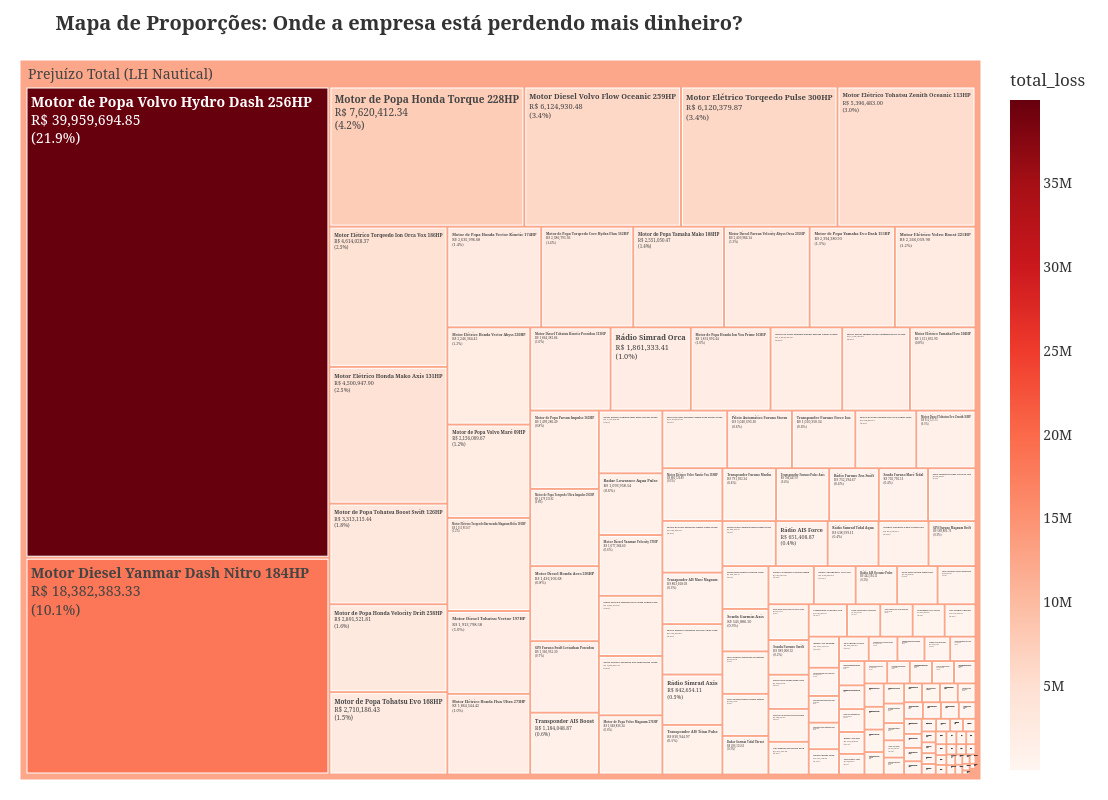

In [8]:
import plotly.express as px

df_loss = df_fct_profitability[df_fct_profitability['total_loss'] > 0].copy()
print(f"Total de produtos com prejuízo: {len(df_loss)}")

fig = px.treemap(
    df_loss,
    path=[px.Constant("Prejuízo Total (LH Nautical)"), 'product_name'],
    values='total_loss',
    color='total_loss',
    color_continuous_scale='Reds',
    title='<b>Mapa de Proporções: Onde a empresa está perdendo mais dinheiro?</b>'
)

fig.update_traces(
    textinfo="label+value+percent parent", 
    texttemplate="<b>%{label}</b><br>R$ %{value:,.2f}<br>(%{percentParent:.1%})",
    hovertemplate="<b>%{label}</b><br>Prejuízo: R$ %{value:,.2f}<extra></extra>"
)

fig.update_layout(
    width=1400,
    height=800,
    margin=dict(t=60, l=20, r=20, b=20),
    font=dict(family="Arial", size=14, color="#333333"),
    template='plotly_white'
)

fig.show()

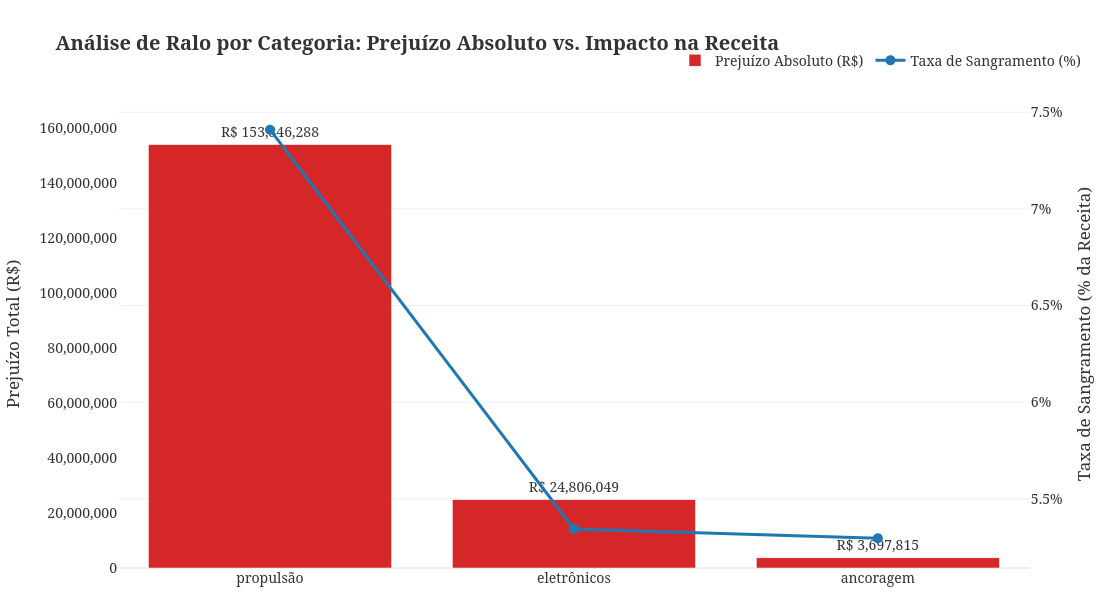

In [5]:
import duckdb
import plotly.graph_objects as go
from plotly.subplots import make_subplots

query_category_drain = """
    SELECT 
        p.actual_category,
        SUM(f.total_revenue) AS total_revenue,
        SUM(f.total_loss) AS total_loss,
        (SUM(f.total_loss) / NULLIF(SUM(f.total_revenue), 0)) * 100 AS drain_rate_pct
    FROM df_fct_profitability f
    JOIN df_products p 
        ON f.id_product = p.code
    WHERE f.total_loss > 0
    GROUP BY p.actual_category
    ORDER BY total_loss DESC
"""

df_category = duckdb.query(query_category_drain).df()

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(
        x=df_category['actual_category'],
        y=df_category['total_loss'],
        name="Prejuízo Absoluto (R$)",
        marker_color='#d62728', 
        text=df_category['total_loss'],
        texttemplate='R$ %{text:,.0f}',
        textposition='outside',
        hovertemplate="<b>%{x}</b><br>Prejuízo: R$ %{y:,.2f}<extra></extra>"
    ),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(
        x=df_category['actual_category'],
        y=df_category['drain_rate_pct'],
        name="Taxa de Sangramento (%)",
        mode='lines+markers',
        line=dict(color='#1f77b4', width=3),
        marker=dict(size=10),
        hovertemplate="<b>%{x}</b><br>Sangramento: %{y:.2f}%<extra></extra>"
    ),
    secondary_y=True,
)

fig.update_layout(
    title='<b>Análise de Ralo por Categoria: Prejuízo Absoluto vs. Impacto na Receita</b>',
    width=1200,
    height=600,
    template='plotly_white',
    hovermode='x unified',
    legend=dict(orientation="h", yanchor="bottom", y=1.05, xanchor="right", x=1),
    margin=dict(t=100, l=20, r=20, b=20),
    font=dict(family="Arial", size=14, color="#333333")
)

fig.update_yaxes(
    title_text="Prejuízo Total (R$)", 
    secondary_y=False, 
    showgrid=False, 
    tickformat=",.0f"
)

fig.update_yaxes(
    title_text="Taxa de Sangramento (% da Receita)", 
    secondary_y=True, 
    showgrid=True, 
    ticksuffix="%"
)

fig.show()